# Efficient implementation of three-part splitting method for Schwarzschild black hole example 

## Loading packages and functions

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings

include("../../src/SplittingMethods.jl")
using .SplittingMethods  ## bertsio lokala exekutatzeko  

include("../Aux_functions.jl")

PATH_ODES="../../ODEProblems/"

# Equations in polar coordinates 
include(string(PATH_ODES,"InitialSchwarzschild.jl"))
include(string(PATH_ODES,"SchwarzschildBH.jl"))
# # Equations in cartesian coordinates 
include(string(PATH_ODES,"InitialSchwarzschildv2.jl"))
include(string(PATH_ODES,"SchwarzschildBHv2.jl"));

##### <a href="#top">Back to the top</a>

## Definition of the problem


### Original equations

We consider a Hamiltonian system describing the motion of charged particles in the vicinity of a Schwarzschild black hole under the influence of an external magnetic field, as studied in [Naying (2022)]:
\begin{align}
\begin{split}
H(r, \theta, p_r, p_{\theta}) &= \frac{1}{2} \left(1 - \frac{2}{r} \right) p_r^2 
- \frac{1}{2} \left(1 - \frac{2}{r} \right)^{-1} E^2 
+ \frac{p_{\theta}^2}{2r^2} \\
&\quad + \frac{1}{2r^2 \sin^2 \theta} \left(L - \frac{\beta}{2} r^2 \sin^2 \theta \right)^2.
\end{split}
\end{align}

This Hamiltonian admits multiple splittings into analytically solvable components---typically into three, four, or five parts. Following the findings of [Naying (2022)], we adopt the three-part splitting
\begin{align}
H = H_A + H_B + H_C,
\end{align}
which was shown to offer the best numerical performance across both regular and chaotic trajectories. The individual components are defined as follows:
\begin{align*}
H_A(r, \theta) &= \frac{1}{2r^2 \sin^2 \theta} \left(L - \frac{\beta}{2} r^2 \sin^2 \theta \right)^2 - \frac{1}{2} \left(1 - \frac{2}{r} \right)^{-1} E^2, \\
H_B(r, p_r, p_\theta) &= \frac{1}{2} \left(p_r^2 + \frac{p_{\theta}^2}{r^2} \right), \\
H_C(r, p_r) &= -\frac{1}{r} p_r^2.
\end{align*}

Although [Naying (2022)] provides analytical expressions for the flows $\varphi_t^A$, $\varphi_t^B$, and $\varphi_t^C$, their direct implementation is computationally inefficient. To enable a fair and representative comparison with our implicit symplectic integrator (IRKGL16), we have improved the evaluation of these flows, significantly enhancing the performance of the explicit method. The derivation and implementation details of this optimized explicit integrator  are presented in the next subsection.


- [Naying (2022)] Naying Zhou, Hongxing Zhang, Wenfang Liu, and Xin Wu.: A note on the con-
struction of explicit symplectic integrators for Schwarzschild spacetimes. The
Astrophysical (2022). DOI 10.3847/1538-4357/ac497f


### Implementation details of this optimized explicit integrator

The evaluation of the flows $\varphi_t^A$ and $\varphi_t^B$ becomes more efficient when performed in the variables $(x, y, p_x, p_y)$, which are related to the original coordinates by the canonical transformation
\begin{align*}
x &= r \cos\theta, \quad y = r \sin\theta, \\
p_x &= \cos\theta \, p_r - \sin\theta \, \frac{p_\theta}{r}, \quad
p_y = \sin\theta \, p_r + \cos\theta \, \frac{p_\theta}{r}.
\end{align*}

In these new variables, the Hamiltonians $H_A$ and $H_B$ become
\begin{align*}
\bar{H}_A(x, y) &= \frac{1}{2 y^2} \left(L - \frac{\beta}{2} y^2 \right)^2 - \frac{1}{2} \left(1 - \frac{2}{\sqrt{x^2 + y^2}} \right)^{-1} E^2, \\
\bar{H}_B(p_x, p_y) &= \frac{1}{2} (p_x^2 + p_y^2).
\end{align*}

For the $H_C$ component, the equations of motion are simplified by introducing the variables $(\nu, \mu)$, defined through the non-canonical transformation
\begin{equation}
\nu = r\, p_r, \quad \mu = \frac{p_r^2}{r}.
\end{equation}
The corresponding equations are
\begin{equation*}
\frac{d\nu}{dt} = -3\mu, \quad \frac{d\mu}{dt} = 0.
\end{equation*}

The flows $\varphi_t^A$, $\varphi_t^B$, and $\varphi_t^C$ and hence the Strang splitting scheme 

\begin{equation}
\phi_h = \varphi^A_{h/2} \circ \varphi^B_{h/2} \circ \varphi^C_{h} \circ \varphi^B_{h/2} \circ \varphi^A_{h/2},
\end{equation}

and extensions to higher-order accuracy can be obtained by symmetric compositions of $s$ basic Strang stages  of the form,

  \begin{align}
  &\psi_{h}= %\phi_{\gamma_{1}h} \circ \phi_{\gamma_{2}h} \circ \cdots \circ  \phi_{\gamma_{s-1}h} \circ 
  \phi_{\gamma_{s}h} \circ \phi_{\gamma_{s-1}h} \circ \dots \circ \phi_{\gamma_{2}h} \circ \phi_{\gamma_{1}h}, \quad \text{with} \ \gamma_{s+1-j}=\gamma_{j}, \ 1\leq j \leq s
  \end{align}


can be efficiently evaluated in the variables $(x, y, p_x, p_y)$ as follows:

-  **Flow of $H_A$**:
    \begin{equation}
        \varphi_t^A: (x, y, p_x, p_y) \mapsto (x, y, p_x^*, p_y^*),
    \end{equation}
    where
    \begin{align}
        p_x^* &= p_x - t\, \frac{\partial \bar{H}_A}{\partial x}(x, y), \\
        p_y^* &= p_y - t\, \frac{\partial \bar{H}_A}{\partial y}(x, y).
    \end{align}

-  **Flow of $H_B$**:
    \begin{equation}
        \varphi_t^B: (x, y, p_x, p_y) \mapsto (x^*, y^*, p_x, p_y),
    \end{equation}
    where
    \begin{align}
        x^* &= x + t\, p_x, \quad y^* = y + t\, p_y.
    \end{align}

-  **Flow of $H_C$**:
    \begin{equation}
        \varphi_t^C: (x, y, p_x, p_y) \mapsto (x^*, y^*, p_x^*, p_y^*),
    \end{equation}
    where
    \begin{align}
        r &= \sqrt{x^2 + y^2}, \quad c = \frac{x}{r}, \quad s = \frac{y}{r}, \\
        p_\theta &= -y\, p_x + x\, p_y, \quad
        \nu = x\, p_x + y\, p_y, \quad
        \mu = \frac{\nu^2}{r^3}, \\
        \nu^* &= \nu - 3t\, \mu, \quad
        p_r^* = (\mu\, \nu^*)^{1/3}, \quad
        r^* = \frac{\nu^*}{p_r^*}, \\
        x^* &= r^*\, c, \quad y^* = r^*\, s, \\
        p_x^* &= c\, p_r^* - s\, \frac{p_\theta}{r^*}, \quad
        p_y^* = s\, p_r^* + c\, \frac{p_\theta}{r^*}.
    \end{align}

The partial derivatives of $\bar{H}_A(x, y)$ can be computed efficiently using the intermediate variables:
\begin{align*}
z &= y^2, \quad r = \sqrt{x^2 + z}, \quad w = L - \frac{\beta}{2} z, \quad u = 1 - \frac{2}{r}, \\
W &= -\frac{w}{z}, \quad U = -\frac{E^2}{2 u^2}, \quad R = \frac{U}{r^3}, \quad Z = R + \frac{(W - \beta) W}{2}, \\
\frac{\partial \bar{H}_A}{\partial x} &= -2x R, \quad
\frac{\partial \bar{H}_A}{\partial y} = -2y Z.
\end{align*}

Unlike the analytical expressions provided in~\cite{Naying2022note} for the flows $\varphi_t^A$, $\varphi_t^B$, and $\varphi_t^C$, our implementation avoids the use of trigonometric and inverse trigonometric functions entirely, resulting in improved computational efficiency.

### Initial value problem

In [2]:
float_type = Float64
#float_type = BigFloat

u0, parms = InitialSchwarzschild(float_type)

HAM=Ham_Schwarzschild
@show(HAM(u0,parms));

HAM(u0, parms) = -0.5


In [3]:
t0=0.
tF=1e5   

tspan= convert.(float_type, (t0,tF));


##### <a href="#top">Back to the top</a>

## Integrations

In [4]:
ddt0_split=collect(0.5:0.25:5)
nruns=100;

### Original equations

In [5]:
flows=[flowH1Schwarzschild!, flowH2Schwarzschild!, flowH3Schwarzschild!]
prob=SplittingProblem(flows, u0, tspan, parms);

In [6]:
s=1; r=2
alg=Splitting_alg(r=r, rkn=false)
sols_split_r2=run_many_Splitting(s, alg, prob, ddt0_split, HAM, nruns=nruns)
#fig=plots_Splitting("Split r=2", alg, prob, HAM, sols_split_r2)
#display(fig)
#
s=5; r=4
alg=Splitting_alg(r=r, rkn=false)
sols_split_r4=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns)
#
s=13; r=6
alg=Splitting_alg(r=r, rkn=false)
sols_split_r6=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns)
#
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns)
#
s=35; r=10
alg=Splitting_alg(r=r, rkn=false)
sols_split_r10=run_many_Splitting(s, alg, prob, s*ddt0_split, HAM, nruns=nruns);

,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.25,3.5,3.75,4.0,4.25,4.5,4.75,5.0,2.5,3.75,5.0,6.25,7.5,8.75,10.0,11.25,12.5,13.75,15.0,16.25,17.5,18.75,20.0,21.25,22.5,23.75,25.0,6.5,9.75,13.0,16.25,19.5,22.75,26.0,29.25,32.5,35.75,39.0,42.25,45.5,48.75,52.0,55.25,58.5,61.75,65.0,10.5,15.75,21.0,26.25,31.5,36.75,42.0,47.25,52.5,57.75,63.0,68.25,73.5,78.75,84.0,89.25,94.5,99.75,105.0,17.5,26.25,35.0,43.75,52.5,61.25,70.0,78.75,87.5,96.25,105.0,113.75,122.5,131.25,140.0,148.75,157.5,166.25,175.0

### Optimized equations

In [7]:
u0_, parms_ = InitialSchwarzschildv2()

flows_=[flowH1Schwarzschildv2!, flowH2Schwarzschildv2!, flowH3Schwarzschildv2!]
prob_=SplittingProblem(flows_, u0_, tspan, parms_);

HAM_=Ham_Schwarzschildv2
@show HAM_(u0_,parms_)

HAM_(u0_, parms_) = -0.5


-0.5

In [8]:
s=1; r=2
alg=Splitting_alg(r=r, rkn=false)
sols_split_r2_=run_many_Splitting(s, alg, prob_, ddt0_split, HAM_, nruns=nruns)
#fig=plots_Splitting("Split r=2", alg, prob, HAMV2, sols_split_r2)
#display(fig)
#
s=5; r=4
alg=Splitting_alg(r=r, rkn=false)
sols_split_r4_=run_many_Splitting(s, alg, prob_, s*ddt0_split, HAM_, nruns=nruns)
#
s=13; r=6
alg=Splitting_alg(r=r, rkn=false)
sols_split_r6_=run_many_Splitting(s, alg, prob_, s*ddt0_split, HAM_, nruns=nruns)
#
s=21; r=8
alg=Splitting_alg(r=r, rkn=false)
sols_split_r8_=run_many_Splitting(s, alg, prob_, s*ddt0_split, HAM_, nruns=nruns)
#
s=35; r=10
alg=Splitting_alg(r=r, rkn=false)
sols_split_r10_=run_many_Splitting(s, alg, prob_, s*ddt0_split, HAM_, nruns=nruns);

,0.5,0.75,1.0,1.25,1.5,1.75,2.0,2.25,2.5,2.75,3.0,3.25,3.5,3.75,4.0,4.25,4.5,4.75,5.0,2.5,3.75,5.0,6.25,7.5,8.75,10.0,11.25,12.5,13.75,15.0,16.25,17.5,18.75,20.0,21.25,22.5,23.75,25.0,6.5,9.75,13.0,16.25,19.5,22.75,26.0,29.25,32.5,35.75,39.0,42.25,45.5,48.75,52.0,55.25,58.5,61.75,65.0,10.5,15.75,21.0,26.25,31.5,36.75,42.0,47.25,52.5,57.75,63.0,68.25,73.5,78.75,84.0,89.25,94.5,99.75,105.0,17.5,26.25,35.0,43.75,52.5,61.25,70.0,78.75,87.5,96.25,105.0,113.75,122.5,131.25,140.0,148.75,157.5,166.25,175.0

<a href="#top">Back to the top</a>

## Benchmarks diagrams

### Work-precison diagrams

In [9]:
sols2plot=[sols_split_r2, sols_split_r4, sols_split_r6, sols_split_r8, sols_split_r10]
labels2plot=["Strang(r=2)", "SUZ90(r=4)", "SS05(r=6)", "SS05(r=8)", "SS05(r=10)"] 
colors2plot=[:orange, :purple, :cyan, :magenta, :teal]

sols2plot_=[sols_split_r2_, sols_split_r4_, sols_split_r6_, sols_split_r8_, sols_split_r10_]
labels2plot_=["Strang(r=2) optimized", "SUZ90(r=4) optimized", "SS05(r=6) optimized", "SS05(r=8) optimized", "SS05(r=10) optimized"] 
colors2plot_=[:orange, :purple, :cyan, :magenta, :teal];

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict

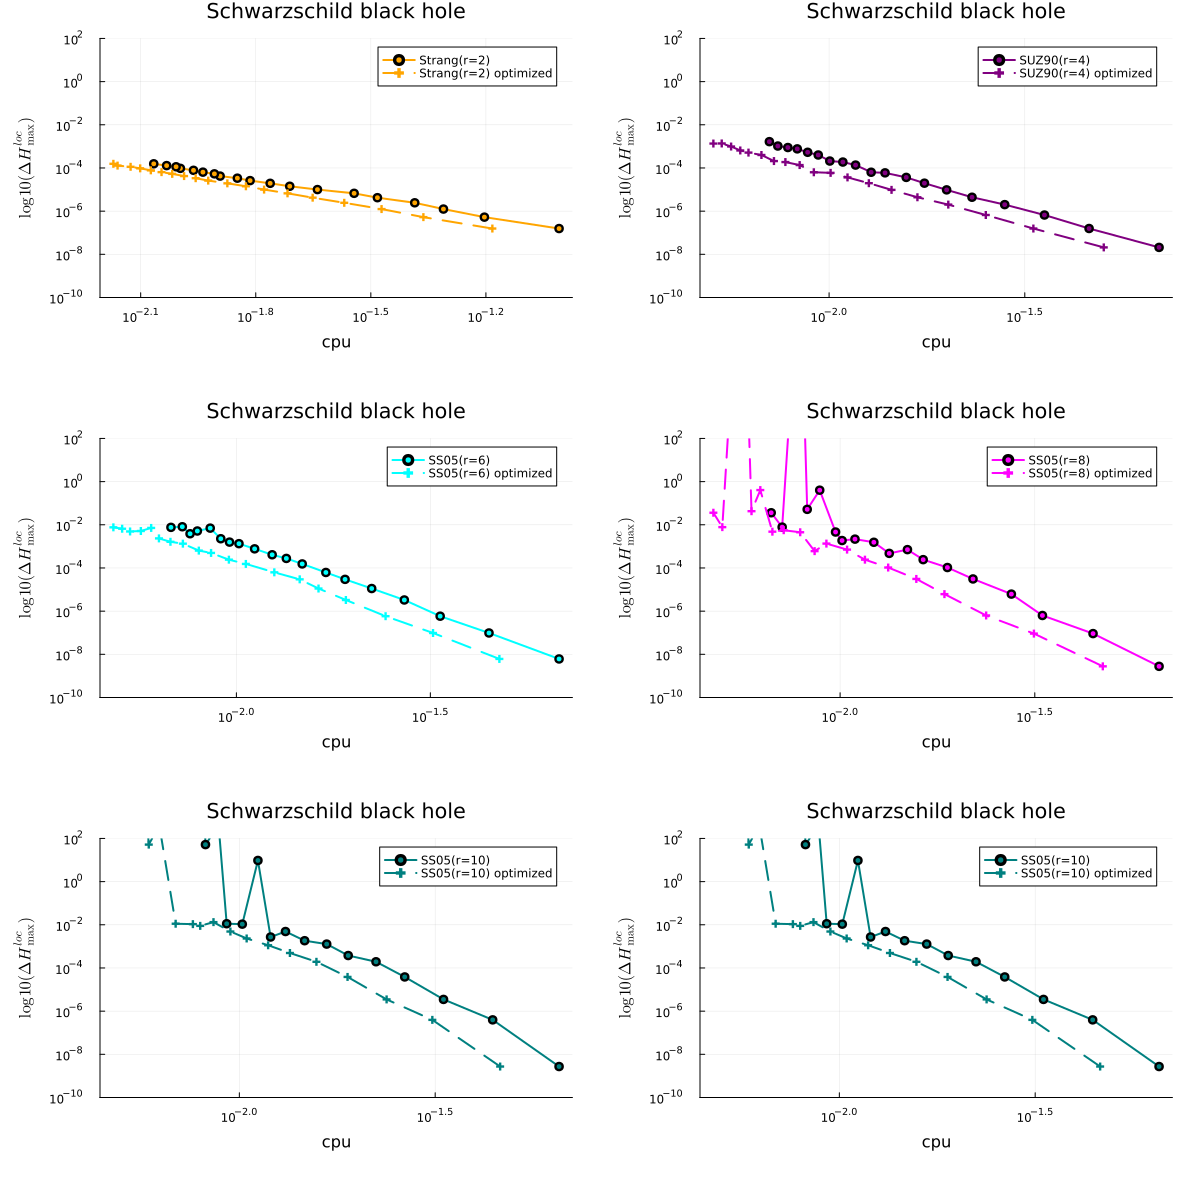

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


In [10]:
yrange=(1e-10, 1e2)
xrange=(1,50)

plotWP = Vector{Plots.Plot}(undef, length(sols2plot))


for k in 1:length(sols2plot)

    plotWP[k]=plot( scale=:log10,
             markershape=:circle, lw=2,
             ylimits=yrange, 
             title="Schwarzschild black hole", xlabel="cpu", ylabel=L"\log10(\Delta H^{loc}_{\mathrm{max}})")

    sols=sols2plot[k]  
    plot!(plotWP[k], sols.cpus , sols.MaxΔHlocal, 
          markershape=:circle, lw=2,
          label=labels2plot[k], color=colors2plot[k],
          scale=:log10)

############################
    
    sols_=sols2plot_[k]
    plot!(plotWP[k], sols_.cpus , sols_.MaxΔHlocal, 
          markershape=:cross, lw=2, ls=:dash,
          label=labels2plot_[k], color=colors2plot_[k],
          scale=:log10)
end


fig=plot(plotWP[1],plotWP[2], 
         plotWP[3],plotWP[4],
         plotWP[5],plotWP[5],
        layout=(3,2), size=(1200,1200), 
    bottom_margin=10Plots.mm,
    left_margin=5Plots.mm, right_margin=5Plots.mm)